<a href="https://colab.research.google.com/github/tkiefaber24/QS-World-University-Rankings/blob/main/QS_World_University_Rankings_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()
########################################
import os
# Check that the file is really there
print("Files in current directory:", os.listdir())

########################################
import shutil

# Make the .kaggle directory
os.makedirs("/root/.kaggle", exist_ok=True)
# Move kaggle.json to that folder
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
# Set file permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)
# Confirm it's there now
print("Files in /root/.kaggle:", os.listdir("/root/.kaggle"))

########################################

from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
print("✅ Kaggle API authentication successful")

########################################

# Download and unzip dataset into 'data' folder
api.dataset_download_files('melissamonfared/qs-world-university-rankings-2025', path='data', unzip=True)
# List downloaded files
print("Downloaded files:", os.listdir("data"))

########################################
# Core Libraries
import pandas as pd
import numpy as np
import re
import warnings

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# --- Settings ---
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

Saving kaggle.json to kaggle.json
Files in current directory: ['.config', 'kaggle.json', 'sample_data']
Files in /root/.kaggle: ['kaggle.json']
✅ Kaggle API authentication successful
Dataset URL: https://www.kaggle.com/datasets/melissamonfared/qs-world-university-rankings-2025
Downloaded files: ['QS World University Rankings 2025 (Top global universities).csv']


In [2]:
import pandas as pd

# Replace the filename with the actual file name from the 'data' folder
df = pd.read_csv('data/QS World University Rankings 2025 (Top global universities).csv', encoding='latin1')

pd.set_option('display.max_columns', None)  # Shows all columns
print(f"Shape of the dataset: {df.shape}")
print("\nDataFrame Info:")
df.info()

print("\nMissing values:\n", df.isnull().sum())

# Show first 10 rows
df.head(10)

Shape of the dataset: (1503, 28)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             1503 non-null   object 
 1   RANK_2024                             1482 non-null   object 
 2   Institution_Name                      1503 non-null   object 
 3   Location                              1503 non-null   object 
 4   Region                                1503 non-null   object 
 5   SIZE                                  1503 non-null   object 
 6   FOCUS                                 1503 non-null   object 
 7   RES.                                  1503 non-null   object 
 8   STATUS                                1466 non-null   object 
 9   Academic_Reputation_Score             1503 non-null   float64
 10  Academic_Reputation_Rank          

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,Academic_Reputation_Rank,Employer_Reputation_Score,Employer_Reputation_Rank,Faculty_Student_Score,Faculty_Student_Rank,Citations_per_Faculty_Score,Citations_per_Faculty_Rank,International_Faculty_Score,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,4,100.0,2,100.0,11,100.0,9,99.3,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,22,99.5,11,98.2,45,93.9,54,100.0,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,2,100.0,5,100.0,8,84.8,93,98.1,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,1,100.0,1,96.3,53,100.0,1,74.1,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,3,100.0,4,100.0,17,84.6,96,100.0,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7
5,6,5,Stanford University,United States,Americas,L,FC,VH,B,100.0,5,100.0,3,100.0,12,99.0,27,70.3,284,60.8,244,96.8,45,100.0,2,81.2,148=,96.1
6,7,7,ETH Zurich - Swiss Federal Institute of Techno...,Switzerland,Europe,L,FO,VH,A,98.8,19,87.2,57,65.9,199,97.9,35,100.0,25,98.6,63,95.7,64,90.5,73,98.8,18,93.9
7,8,8,National University of Singapore (NUS),Singapore,Asia,XL,FC,VH,A,99.5,15,91.1,48,68.8,189,93.1,61,100.0,41,88.9,129,91.6,146,100.0,6,97.7,26=,93.7
8,9,9,UCL,United Kingdom,Europe,XL,FC,VH,A,99.5,14,98.3,18,95.9,56,72.2,145,99.0,106,100.0,21,99.9,2,70.3,157,74.8,190=,91.6
9,10,15,California Institute of Technology (Caltech),United States,Americas,S,CO,VH,B,96.5,29,95.3,33,100.0,4,100.0,5,100.0,65,79.8,172,65.5,549,31.0,407,62.5,253,90.9


In [3]:
#since many of the rank columns are type object it means they likely have non-numeric characters and we need to clean them
def clean_rank(rank_str):
    if pd.isna(rank_str):
        return np.nan
    rank_str = str(rank_str).strip()
    if '-' in rank_str:
        rank_str = rank_str.split('-')[0]
    rank_str = rank_str.replace('=', '').replace('+', '')
    try:
        return float(rank_str)
    except ValueError:
        return np.nan

rank_columns = [col for col in df.columns if 'Rank' in col or 'RANK' in col]
print(f"Identified Rank Columns: {rank_columns}")

print("\nCleaning rank columns...")
for col in rank_columns:
    df[col] = df[col].apply(clean_rank)
print("✅ Rank columns cleaned and converted to numeric.")

Identified Rank Columns: ['RANK_2025', 'RANK_2024', 'Academic_Reputation_Rank', 'Employer_Reputation_Rank', 'Faculty_Student_Rank', 'Citations_per_Faculty_Rank', 'International_Faculty_Rank', 'International_Students_Rank', 'International_Research_Network_Rank', 'Employment_Outcomes_Rank', 'Sustainability_Rank']

Cleaning rank columns...
✅ Rank columns cleaned and converted to numeric.


In [4]:
unique_scores = df['Overall_Score'].dropna().unique()
print(f"Number of unique non-null values in 'Overall_Score': {len(unique_scores)}")

if len(unique_scores) > 0:
    sample_value = df['Overall_Score'].dropna().iloc[0]
    print(f"Data type of a sample score ('{sample_value}'): {type(sample_value)}")
    print("🕵️ Observation: Scores are stored as strings, need conversion.")
else:
    print("'Overall_Score' column has no non-null values to sample.")

Number of unique non-null values in 'Overall_Score': 363
Data type of a sample score ('100'): <class 'str'>
🕵️ Observation: Scores are stored as strings, need conversion.


In [5]:
df['Overall_Score'] = pd.to_numeric(df['Overall_Score'], errors='coerce')

print("\n--- 🔢 Descriptive Statistics (Numeric Columns) ---")
display(df.describe())

print("\n--- 🔠 Descriptive Statistics (Categorical Columns) ---")
display(df.describe(include='object'))


--- 🔢 Descriptive Statistics (Numeric Columns) ---


,RANK_2025,RANK_2024,Academic_Reputation_Score,Academic_Reputation_Rank,Employer_Reputation_Score,Employer_Reputation_Rank,Faculty_Student_Score,Faculty_Student_Rank,Citations_per_Faculty_Score,Citations_per_Faculty_Rank,International_Faculty_Score,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
count,1503.000000,1482.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1403.000000,1403.000000,1445.000000,1445.000000,1502.000000,1502.000000,1503.000000,1503.000000,1484.000000,1484.000000,600.000000
mean,716.898869,708.524966,20.286693,481.039920,19.787292,481.039920,28.128676,541.487691,23.503460,537.750499,30.736707,529.513186,25.580346,533.277509,50.129095,537.651132,23.825083,539.006653,24.309299,535.223046,41.840333
std,399.086239,393.783867,22.326168,183.455691,23.784738,183.455691,27.613017,221.420249,27.870692,222.753321,34.344365,224.940510,31.098689,224.194177,29.866588,222.787150,27.351315,222.472165,31.074718,223.635377,18.826756
min,1.000000,1.000000,1.300000,1.000000,1.100000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.200000,1.000000,1.000000,1.000000,20.800000
25%,376.000000,369.500000,6.300000,376.500000,4.300000,376.500000,7.300000,386.500000,2.800000,376.500000,4.200000,359.500000,2.900000,365.000000,22.725000,376.250000,4.000000,379.500000,1.300000,371.000000,26.575000
50%,741.000000,741.000000,11.000000,601.000000,9.400000,601.000000,16.000000,701.000000,9.900000,701.000000,12.500000,701.000000,9.600000,701.000000,51.100000,701.000000,11.800000,701.000000,6.750000,701.000000,36.350000
75%,1001.000000,1001.000000,23.500000,601.000000,25.300000,601.000000,40.400000,701.000000,36.400000,701.000000,51.600000,701.000000,38.300000,701.000000,77.100000,701.000000,33.400000,701.000000,39.500000,701.000000,52.100000
max,1401.000000,1401.000000,100.000000,601.000000,100.000000,601.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000



--- 🔠 Descriptive Statistics (Categorical Columns) ---


,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS
count,1503,1503,1503,1503,1503,1503,1466
unique,1503,106,6,4,4,4,3
top,Western Washington University,United States,Asia,L,FC,VH,A
freq,1,197,501,691,592,1021,1165


<Figure size 1200x600 with 0 Axes>

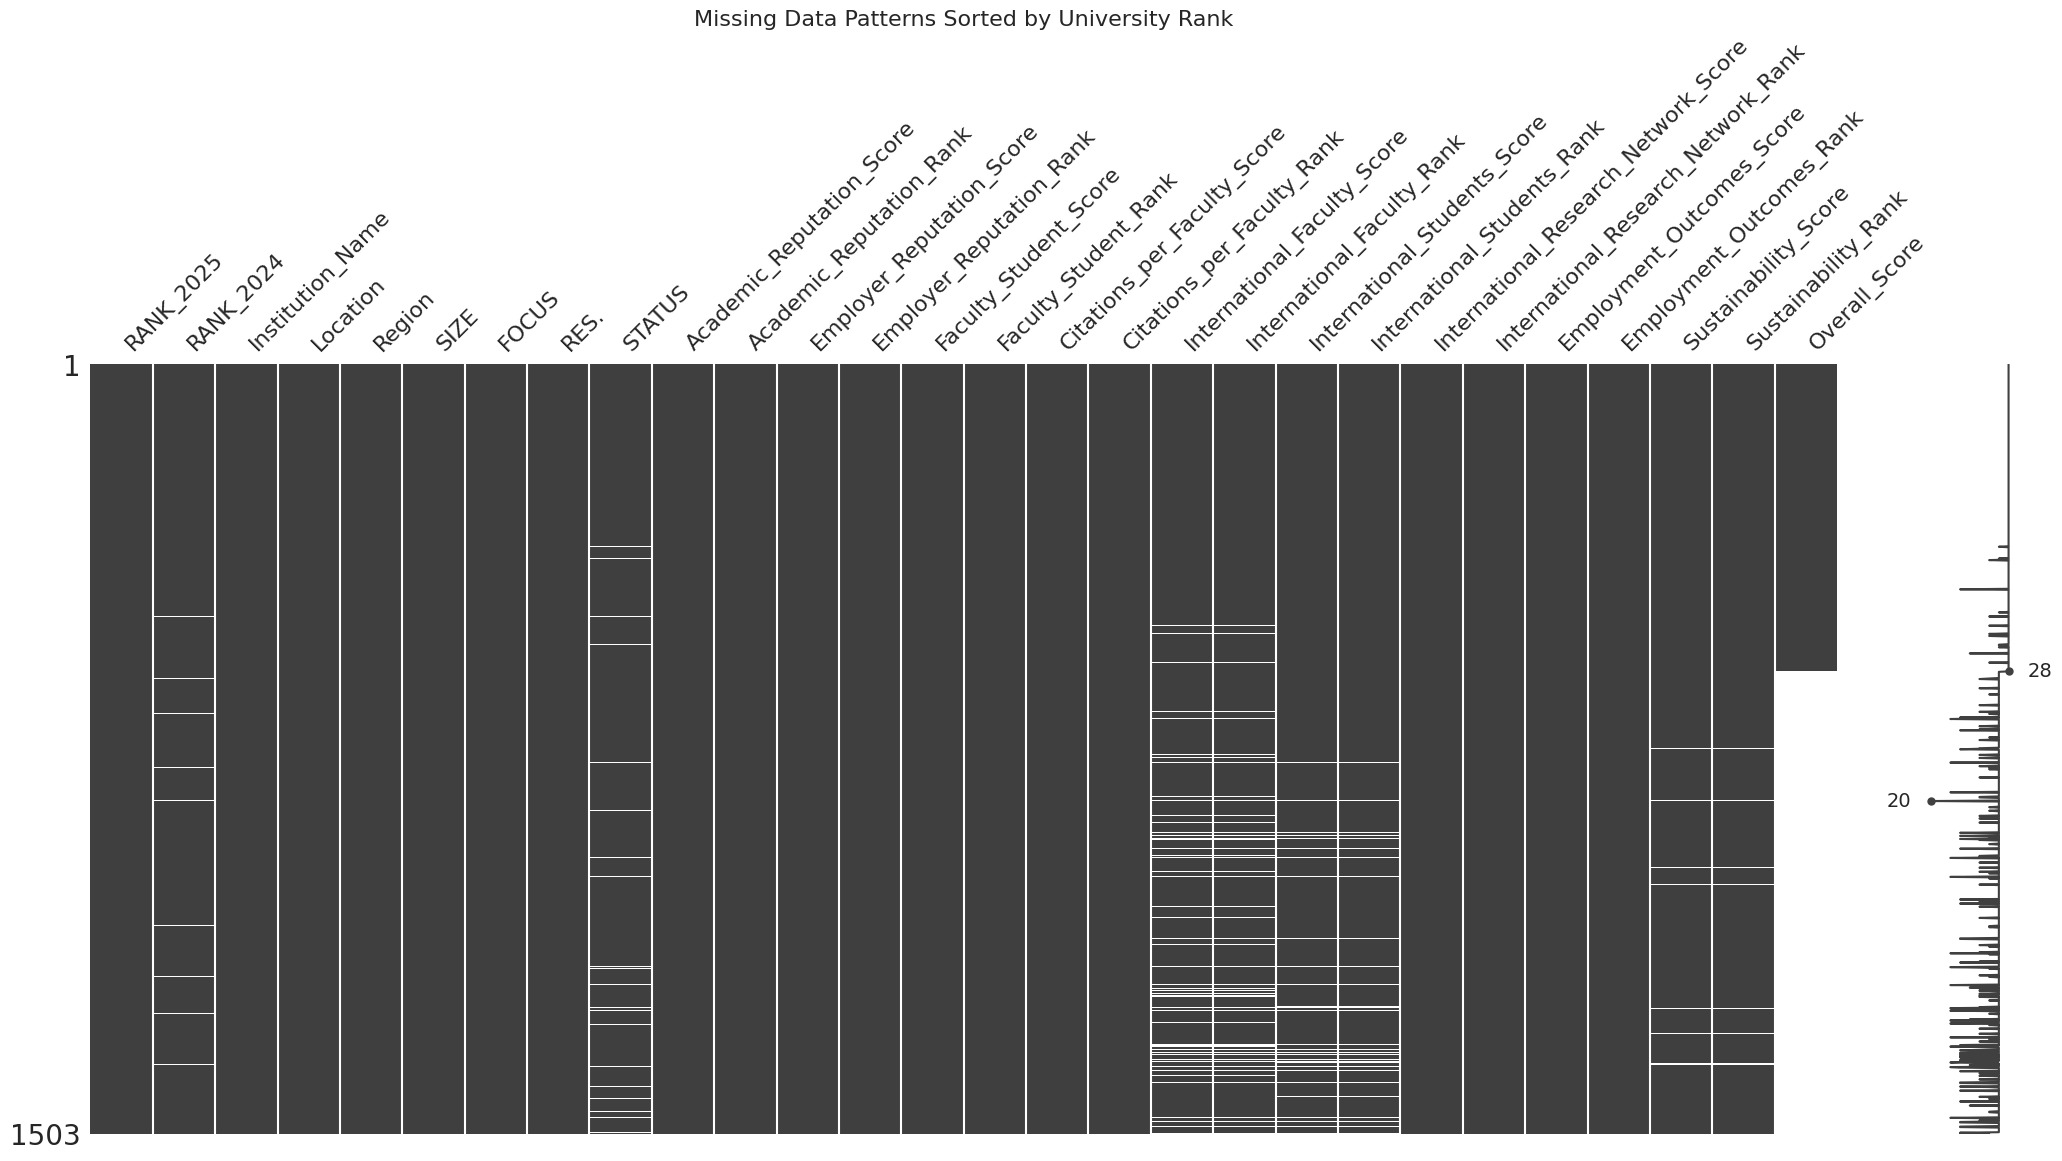

In [ ]:
# Sort by 'RANK_2025' and visualize
df2 = df.copy()
df2['RANK_2025'] = pd.to_numeric(df2['RANK_2025'], errors='coerce')
df2_sorted = df2.sort_values(by='RANK_2025')

plt.figure(figsize=(12, 6))
msno.matrix(df2_sorted)
plt.title('Missing Data Patterns Sorted by University Rank', fontsize=16)
plt.show()

#this shows that data where overall score are NaNs are when RANK_2025 is low

In [25]:
columns_to_check = ['Overall_Score', 'Academic_Reputation_Score', 'Employer_Reputation_Score','Faculty_Student_Score', 'Citations_per_Faculty_Score', 'International_Faculty_Score', 'International_Students_Score', 'International_Research_Network_Score', 'Employment_Outcomes_Score', 'Sustainability_Score']
df_cleaned = df.dropna(subset=columns_to_check)
print(f"Shape of the dataset after dropping nulls: {df_cleaned.shape}")

Shape of the dataset after dropping nulls: (593, 28)


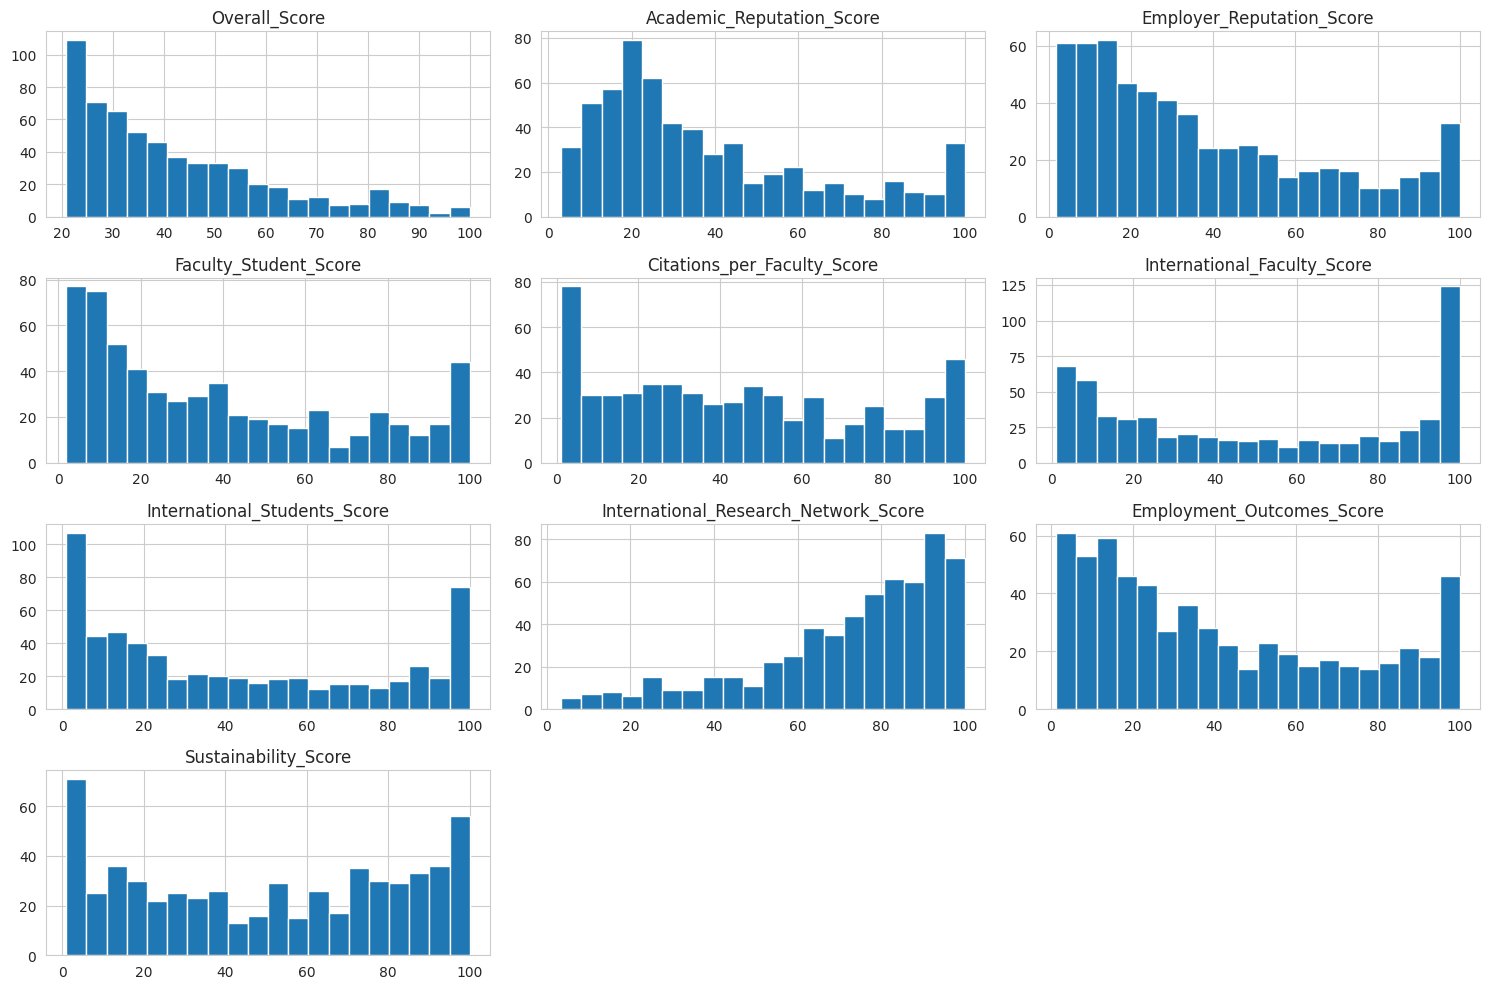

In [26]:
import matplotlib.pyplot as plt

columns_to_plot = ['Overall_Score', 'Academic_Reputation_Score', 'Employer_Reputation_Score','Faculty_Student_Score', 'Citations_per_Faculty_Score', 'International_Faculty_Score', 'International_Students_Score', 'International_Research_Network_Score', 'Employment_Outcomes_Score', 'Sustainability_Score']

df_cleaned[columns_to_plot].hist(figsize=(15, 10), bins=20)
plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

In [ ]:
display(df_cleaned.describe())

,RANK_2025,RANK_2024,Academic_Reputation_Score,Academic_Reputation_Rank,Employer_Reputation_Score,Employer_Reputation_Rank,Faculty_Student_Score,Faculty_Student_Rank,Citations_per_Faculty_Score,Citations_per_Faculty_Rank,International_Faculty_Score,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
count,593.000000,589.000000,593.000000,593.00000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000,593.000000
mean,297.392917,301.694397,37.995616,319.06914,37.318718,340.989882,38.655143,458.733558,44.440809,366.448567,50.910118,398.715008,42.254300,412.239460,72.679933,370.182125,40.412648,402.200675,50.430860,345.229342,42.045531
std,172.332956,187.216393,26.593448,195.21190,28.511772,207.383971,30.854524,245.970355,31.052633,234.636452,36.715488,238.917494,34.724691,242.245652,22.695175,236.232379,30.847332,241.440459,32.938244,226.627123,18.839196
min,1.000000,1.000000,3.100000,1.00000,1.800000,1.000000,1.900000,3.000000,1.100000,1.000000,1.100000,1.000000,1.000000,1.000000,3.500000,1.000000,1.300000,1.000000,1.000000,1.000000,20.800000
25%,149.000000,148.000000,18.200000,149.00000,13.500000,151.000000,11.400000,224.000000,17.500000,155.000000,14.200000,180.000000,10.600000,184.000000,62.200000,160.000000,14.300000,181.000000,18.400000,148.000000,26.700000
50%,297.000000,295.000000,29.500000,300.00000,28.800000,330.000000,30.800000,512.000000,40.700000,344.000000,46.300000,388.000000,32.200000,412.000000,78.800000,340.000000,31.900000,395.000000,52.100000,305.000000,36.600000
75%,445.000000,441.000000,53.800000,499.00000,55.300000,600.000000,62.300000,701.000000,70.000000,590.000000,91.600000,679.000000,75.600000,701.000000,90.700000,603.000000,64.500000,681.000000,81.200000,549.000000,52.200000
max,596.000000,1401.000000,100.000000,601.00000,100.000000,601.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000,701.000000,100.000000


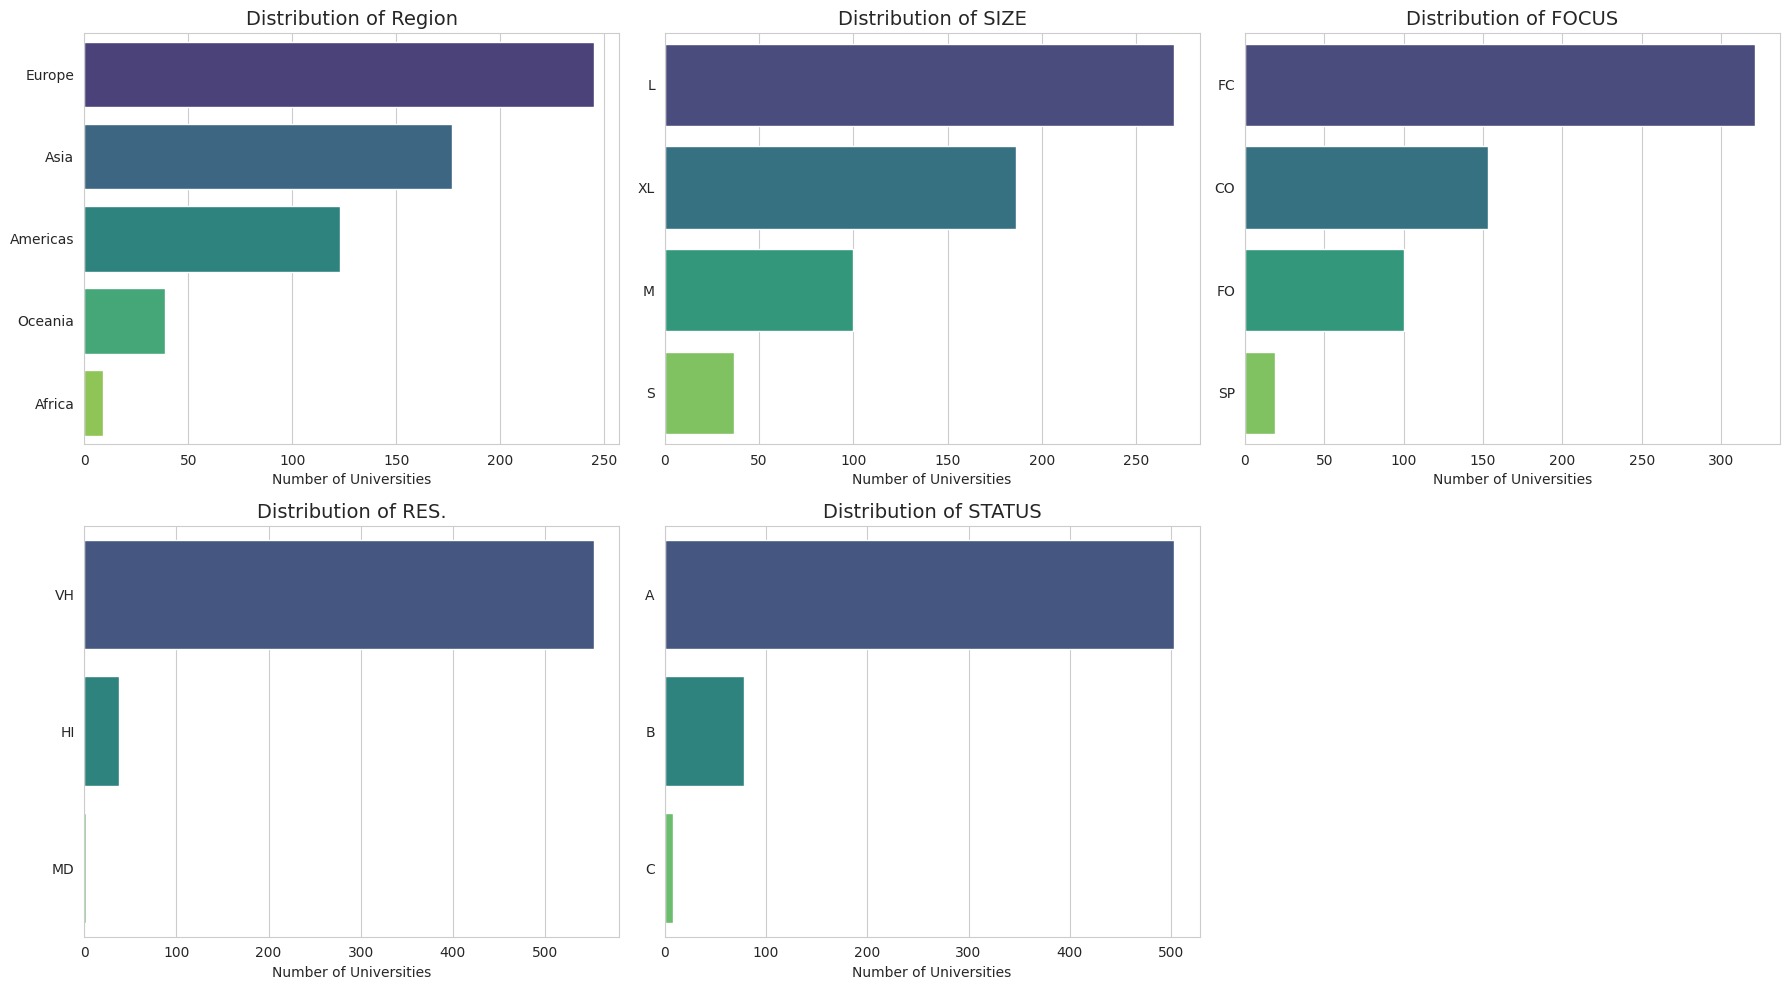

In [ ]:
cat_cols = ['Region', 'SIZE', 'FOCUS', 'RES.', 'STATUS']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df_cleaned[col].value_counts().index
    sns.countplot(data=df_cleaned, y=col, ax=axes[i], palette='viridis', order=order)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('Number of Universities')
    axes[i].set_ylabel('')

if len(cat_cols) < len(axes):
    for j in range(len(cat_cols), len(axes)):
        axes[j].set_visible(False)

plt.tight_layout()
plt.show()

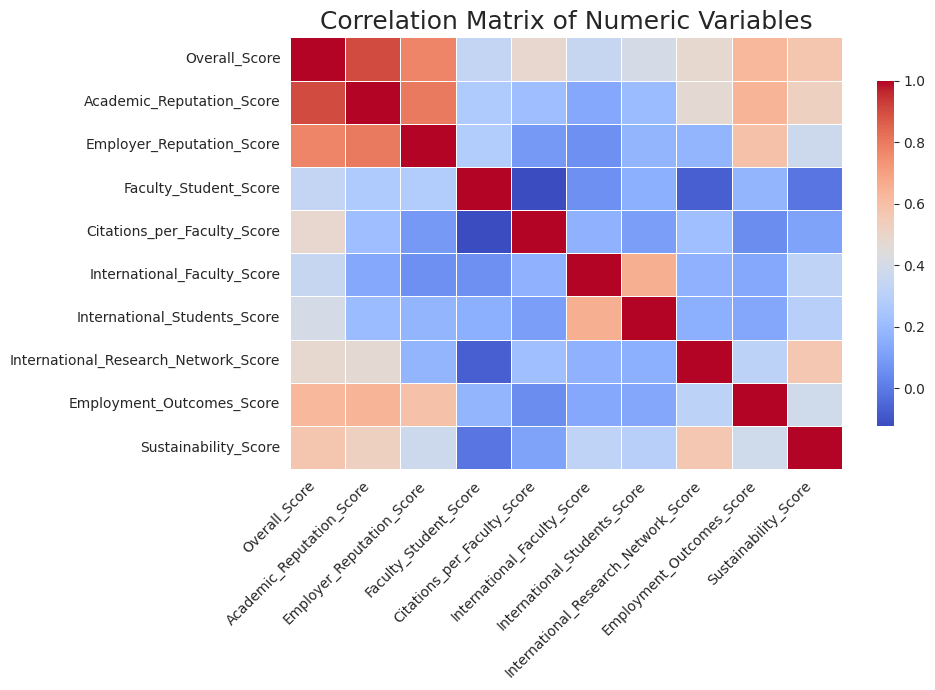

In [ ]:
numeric_df = df_cleaned[['Overall_Score', 'Academic_Reputation_Score', 'Employer_Reputation_Score','Faculty_Student_Score', 'Citations_per_Faculty_Score', 'International_Faculty_Score', 'International_Students_Score', 'International_Research_Network_Score', 'Employment_Outcomes_Score', 'Sustainability_Score']]
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=.5,
            cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Numeric Variables', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

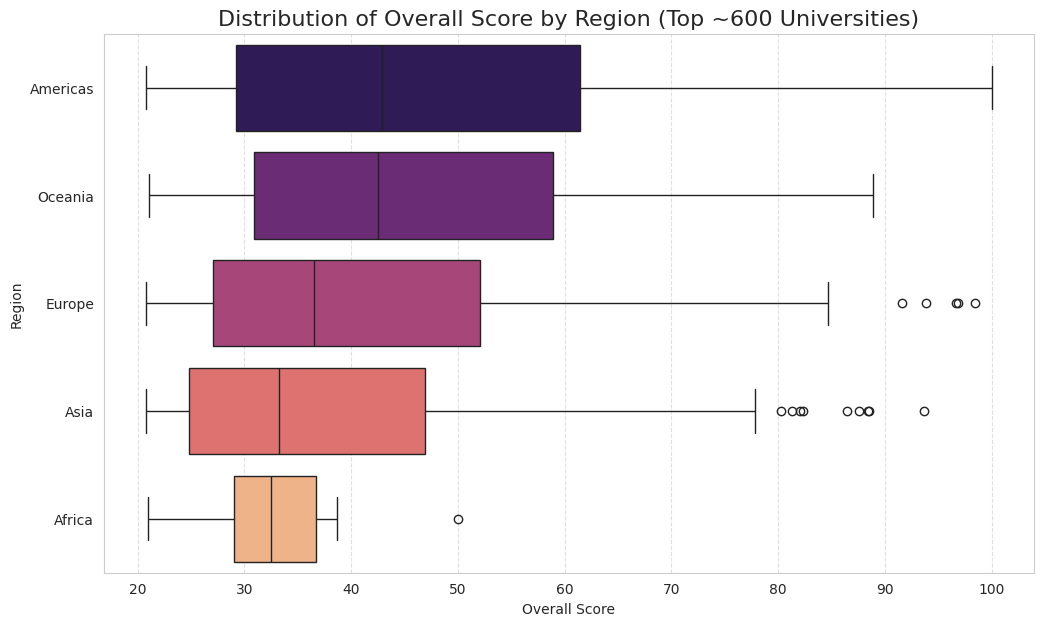

In [ ]:
plt.figure(figsize=(12, 7))
region_order = df_cleaned.groupby('Region')['Overall_Score'].median().sort_values(ascending=False).index
sns.boxplot(data=df_cleaned.dropna(subset=['Overall_Score']),
            x='Overall_Score', y='Region', order=region_order, palette='magma')
plt.title('Distribution of Overall Score by Region (Top ~600 Universities)', fontsize=16)
plt.xlabel('Overall Score')
plt.ylabel('Region')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import statsmodels.formula.api as sm

# Define the formula for the model
formula = 'Overall_Score ~ Academic_Reputation_Score + Employer_Reputation_Score + Faculty_Student_Score + Citations_per_Faculty_Score + International_Faculty_Score + International_Students_Score + International_Research_Network_Score + Employment_Outcomes_Score + Sustainability_Score'

# Fit the OLS model
model = sm.ols(formula, data=df_cleaned)
results = model.fit()

# Print the summary of the model
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Overall_Score   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.733e+07
Date:                Sat, 26 Apr 2025   Prob (F-statistic):               0.00
Time:                        01:54:43   Log-Likelihood:                 1258.5
No. Observations:                 593   AIC:                            -2497.
Df Residuals:                     583   BIC:                            -2453.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


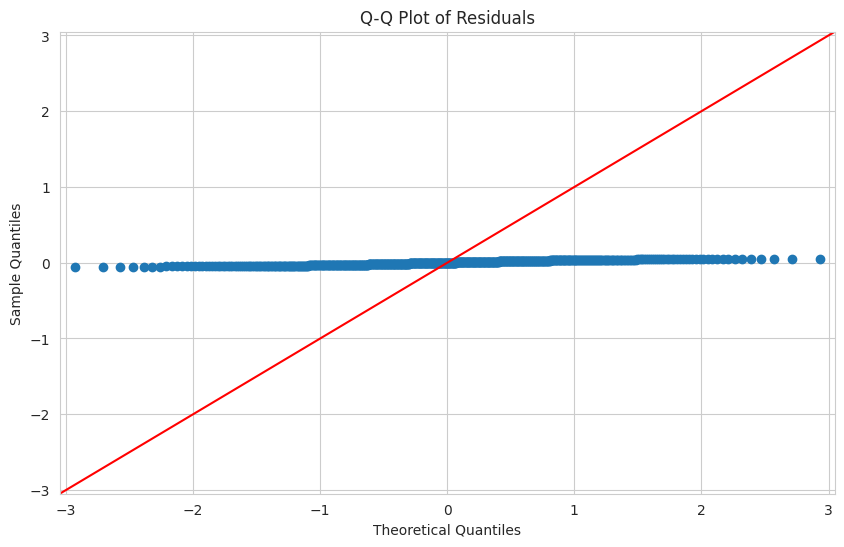

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Get the residuals from the model
residuals = results.resid

# Create the Q-Q plot
sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot of Residuals')
plt.show()

In [ ]:
import statsmodels.formula.api as sm

# Define the formula for the model
formula = 'Overall_Score ~ Academic_Reputation_Score'

# Fit the OLS model
model = sm.ols(formula, data=df_cleaned)
results = model.fit()

# Print the summary of the model
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Overall_Score   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     2567.
Date:                Sat, 26 Apr 2025   Prob (F-statistic):          3.22e-217
Time:                        01:54:59   Log-Likelihood:                -2085.1
No. Observations:                 593   AIC:                             4174.
Df Residuals:                     591   BIC:                             4183.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
import statsmodels.formula.api as sm

# Define the formula for the model
formula = 'Overall_Score ~ Academic_Reputation_Score + Sustainability_Score'

# Fit the OLS model
model = sm.ols(formula, data=df_cleaned)
results = model.fit()

# Print the summary of the model
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Overall_Score   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     1397.
Date:                Sat, 26 Apr 2025   Prob (F-statistic):          1.76e-224
Time:                        01:55:02   Log-Likelihood:                -2064.1
No. Observations:                 593   AIC:                             4134.
Df Residuals:                     590   BIC:                             4147.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
import statsmodels.formula.api as sm

# Define the formula for the model
formula = 'Overall_Score ~ Sustainability_Score'

# Fit the OLS model
model = sm.ols(formula, data=df_cleaned)
results = model.fit()

# Print the summary of the model
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Overall_Score   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     285.5
Date:                Sat, 26 Apr 2025   Prob (F-statistic):           1.49e-52
Time:                        01:55:05   Log-Likelihood:                -2465.1
No. Observations:                 593   AIC:                             4934.
Df Residuals:                     591   BIC:                             4943.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               25.5828 

In [27]:
import statsmodels.formula.api as sm

# Define the formula for the model
formula = 'Overall_Score ~ Employment_Outcomes_Score'

# Fit the OLS model
model = sm.ols(formula, data=df_cleaned)
results = model.fit()

# Print the summary of the model
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Overall_Score   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     380.7
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           8.02e-66
Time:                        02:56:18   Log-Likelihood:                -2434.5
No. Observations:                 593   AIC:                             4873.
Df Residuals:                     591   BIC:                             4882.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
#going back to academic score and using sklearn for it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd

# Define X and y
X = df_cleaned[['Academic_Reputation_Score']]
y = df_cleaned['Overall_Score']

# Split into train and remaining data (for dev and test)
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, test_size=0.3, random_state=42) #70% split

# Split remaining data into dev and test
X_dev, X_test, y_dev, y_test = train_test_split(X_remaining, y_remaining, test_size=0.5, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on dev and test sets
y_pred_dev = model.predict(X_dev)
y_pred_test = model.predict(X_test)

# Calculate R-squared & RMSE for dev and test sets
r2_dev_linreg = r2_score(y_dev, y_pred_dev)
rmse_dev_linreg = mean_squared_error(y_dev, y_pred_dev)**0.5
r2_test_linreg = r2_score(y_test, y_pred_test)
rmse_test_linreg = mean_squared_error(y_test, y_pred_test)**0.5

# Calculate adjusted R-squared for dev and test sets
n_dev = len(y_dev)  # Number of observations in dev set
k = X_dev.shape[1]  # Number of independent variables
adj_r2_dev_linreg = 1 - (1 - r2_dev_linreg) * (n_dev - 1) / (n_dev - k - 1)

n_test = len(y_test)  # Number of observations in test set
adj_r2_test_linreg = 1 - (1 - r2_test_linreg) * (n_test - 1) / (n_test - k - 1)

# Print the results
print(f"R-squared (Dev Set): {r2_dev_linreg}")
print(f"Adjusted R-squared (Dev Set): {adj_r2_dev_linreg}")
print(f"RMSE (Dev Set): {rmse_dev_linreg}")
print(f"R-squared (Test Set): {r2_test_linreg}")
print(f"Adjusted R-squared (Test Set): {adj_r2_test_linreg}")
print(f"RMSE (Test Set): {rmse_test_linreg}")
# Here adjusted r squared and normal r squared should be same because we only have one independent variable

R-squared (Dev Set): 0.7995776763814862
Adjusted R-squared (Dev Set): 0.7972739715123079
RMSE (Dev Set): 7.998356237584577
R-squared (Test Set): 0.8492192562309493
Adjusted R-squared (Test Set): 0.8474861442336039
RMSE (Test Set): 8.089787298988472


In [ ]:
#now we have a baseline, let's see if xgboost performs better
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

# Define X and y
X = df_cleaned[['Academic_Reputation_Score']]
y = df_cleaned['Overall_Score']

# Split into train and remaining data (for dev and test)
X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, test_size=0.3, random_state=42) #70% split

# Split remaining data into dev and test
X_dev, X_test, y_dev, y_test = train_test_split(X_remaining, y_remaining, test_size=0.5, random_state=42)

# Create and train the XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

# Make predictions on dev and test sets
y_pred_dev = model.predict(X_dev)
y_pred_test = model.predict(X_test)

# Calculate R-squared for dev and test sets
r2_dev_xgbase = r2_score(y_dev, y_pred_dev)
r2_test_xgbase = r2_score(y_test, y_pred_test)

# Calculate adjusted R-squared for dev and test sets
n_dev = len(y_dev)  # Number of observations in dev set
k = X_dev.shape[1]  # Number of independent variables
adj_r2_dev_xgbase = 1 - (1 - r2_dev_xgbase) * (n_dev - 1) / (n_dev - k - 1)

n_test = len(y_test)  # Number of observations in test set
adj_r2_test_xgbase = 1 - (1 - r2_test_xgbase) * (n_test - 1) / (n_test - k - 1)

# Calculate Root Mean Squared Error (RMSE) for dev and test sets
rmse_dev_xgbase = mean_squared_error(y_dev, y_pred_dev)**0.5
rmse_test_xgbase = mean_squared_error(y_test, y_pred_test)**0.5

# Print the results
print(f"R-squared (Dev Set): {r2_dev_xgbase}")
print(f"Adjusted R-squared (Dev Set): {adj_r2_dev_xgbase}")
print(f"RMSE (Dev Set): {rmse_dev_xgbase}")
print(f"R-squared (Test Set): {r2_test_xgbase}")
print(f"Adjusted R-squared (Test Set): {adj_r2_test_xgbase}")
print(f"RMSE (Test Set): {rmse_test_xgbase}")

R-squared (Dev Set): 0.6286990577628002
Adjusted R-squared (Dev Set): 0.6244312308405335
RMSE (Dev Set): 10.886561302345505
R-squared (Test Set): 0.8318996946271013
Adjusted R-squared (Test Set): 0.829967507209022
RMSE (Test Set): 8.541780628756959


In [ ]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data
X = df_cleaned[['Academic_Reputation_Score']]
y = df_cleaned['Overall_Score']

# Split into Train+Dev and Test
X_train_dev, X_test, y_train_dev, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the base model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define hyperparameter grid (example)
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.1, 0.5, 1.0],
    'n_estimators': [100, 200],
    #'alpha': [0, 0.1, 1],  # L1 regularization
    'lambda': [0.1, 1, 2]  # L2 regularization
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit to Train + Dev set
grid_search.fit(X_train_dev, y_train_dev)

# Best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Evaluate on Train+Dev set
y_pred_train_dev = best_model.predict(X_train_dev)
rmse_train_dev_xggridcv = mean_squared_error(y_train_dev, y_pred_train_dev)**0.5 # RMSE
r2_train_dev_xggridcv = r2_score(y_train_dev, y_pred_train_dev)

# Evaluate on Test set
y_pred_test = best_model.predict(X_test)
rmse_test_xggridcv = mean_squared_error(y_test, y_pred_test)**0.5  # RMSE
r2_test_xggridcv = r2_score(y_test, y_pred_test)

# Output
print("Best Parameters:", best_params)
print("Train+Dev RMSE:", rmse_train_dev_xggridcv)
print("Train+Dev R-squared:", r2_train_dev_xggridcv)
print("Test RMSE:", rmse_test_xggridcv)
print("Test R-squared:", r2_test_xggridcv)

# Feature Importances
print("\nFeature Importances:")
for feature, importance in zip(X.columns, best_model.feature_importances_):
    print(f"{feature}: {importance:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'lambda': 2, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Train+Dev RMSE: 6.796667802995328
Train+Dev R-squared: 0.8687380099833241
Test RMSE: 8.217985023797503
Test R-squared: 0.8140213513303827

Feature Importances:
Academic_Reputation_Score: 1.0000


In [ ]:
# Comparing all models (transposed version)
comparison_df = pd.DataFrame({
    'Metric': ['R2 (Dev)', 'R2 (Test)', 'RMSE (Dev)', 'RMSE (Test)'],
    'Linear Regression Model': [r2_dev_linreg, r2_test_linreg, rmse_dev_linreg, rmse_test_linreg],
    'XG Boost Baseline Model': [r2_dev_xgbase, r2_test_xgbase, rmse_dev_xgbase, rmse_test_xgbase],
    'XG Boost Grid Search CV Model': [r2_train_dev_xggridcv, r2_test_xggridcv, rmse_train_dev_xggridcv, rmse_test_xggridcv]
})

# Transpose the table
comparison_df = comparison_df.set_index('Metric').T

# Display
print("\nModel Performance Comparison:")
print(comparison_df)



Model Performance Comparison:
Metric                         R2 (Dev)  R2 (Test)  RMSE (Dev)  RMSE (Test)
Linear Regression Model        0.799578   0.849219    7.998356     8.089787
XG Boost Baseline Model        0.628699   0.831900   10.886561     8.541781
XG Boost Grid Search CV Model  0.868738   0.814021    6.796668     8.217985


In [ ]:
# Example: Create new data for prediction
new_data = pd.DataFrame({
    'Academic_Reputation_Score': [96, 90, 75, 60]  # remember the min academic score is 3 so we can't input a number below that and expect an accurate prediction
})

# Predict using the best model found
predictions = best_model.predict(new_data)

# Display results
for score, prediction in zip(new_data['Academic_Reputation_Score'], predictions):
    print(f"Predicted Overall_Score for Academic_Reputation_Score {score}: {prediction:.2f}")


Predicted Overall_Score for Academic_Reputation_Score 96: 79.10
Predicted Overall_Score for Academic_Reputation_Score 90: 76.43
Predicted Overall_Score for Academic_Reputation_Score 75: 72.51
Predicted Overall_Score for Academic_Reputation_Score 60: 54.03


In [ ]:
#Looking into specific comparisons
#What are the top 20 ranked?
#Between 2024 and 2025 how much did they change? or do the top 20 sort of rotate?
#How do the top 20 ranked compare to the rest of the group? Region, size, etc.
#How correlated is overall score to high rank? the most correlated
#Does high rank equate to high employability?
#What does high rank equate most to? Academic score?

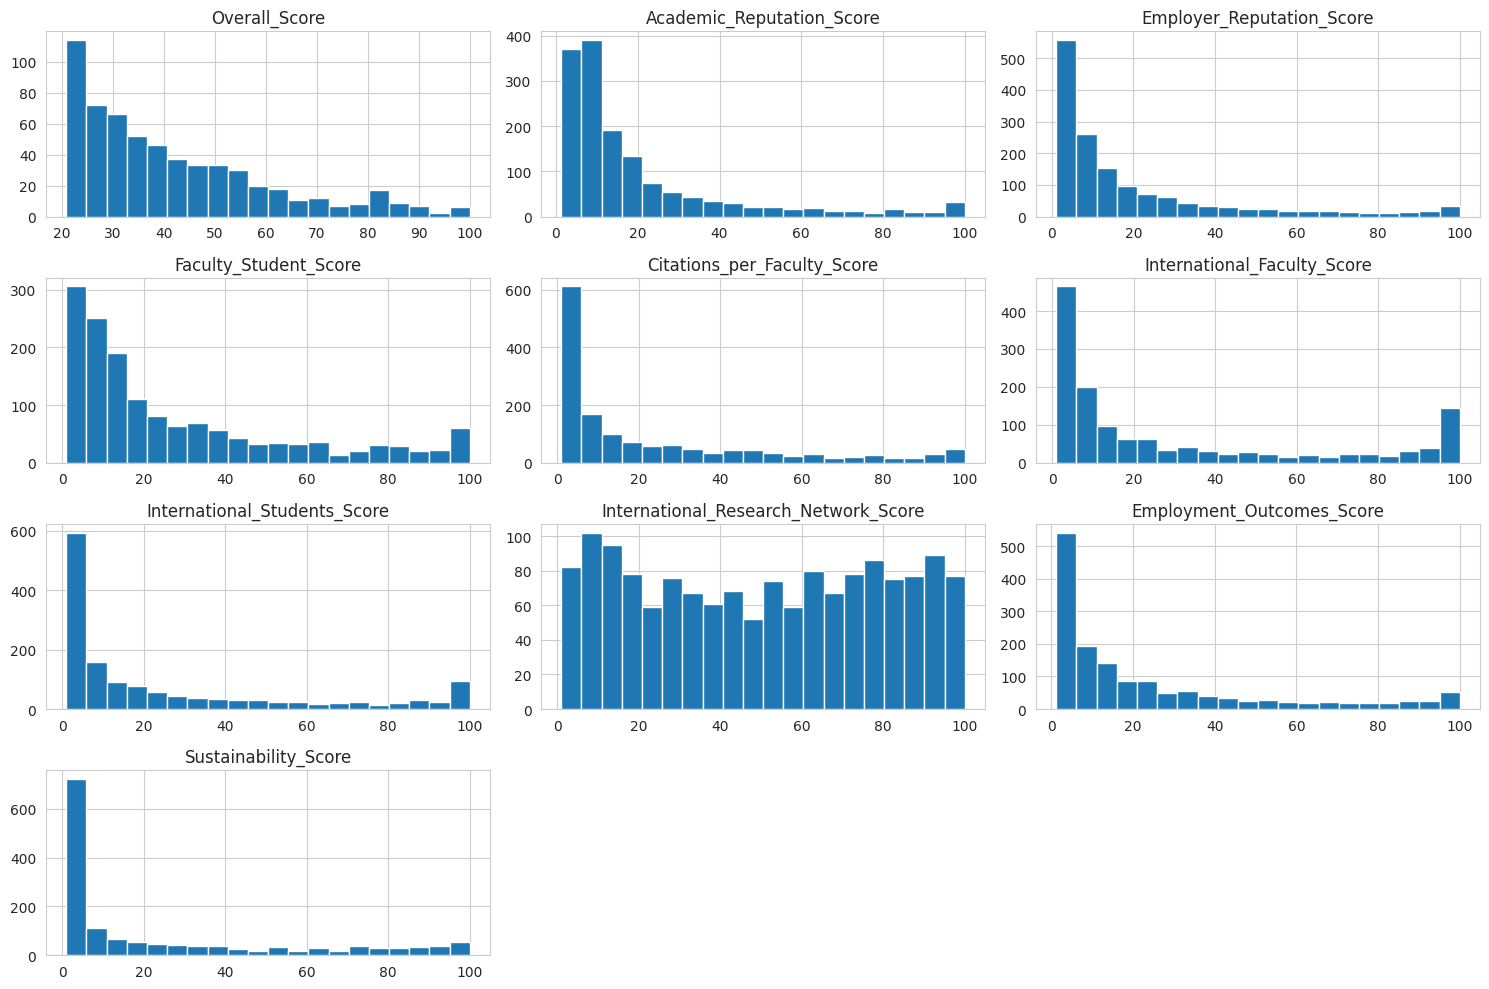

In [8]:
import matplotlib.pyplot as plt

columns_to_plot = ['Overall_Score', 'Academic_Reputation_Score', 'Employer_Reputation_Score','Faculty_Student_Score', 'Citations_per_Faculty_Score', 'International_Faculty_Score', 'International_Students_Score', 'International_Research_Network_Score', 'Employment_Outcomes_Score', 'Sustainability_Score']

df[columns_to_plot].hist(figsize=(15, 10), bins=20)
plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

In [7]:
df[['RANK_2025','RANK_2024','Institution_Name']].head(50)

,RANK_2025,RANK_2024,Institution_Name
0,1.0,1.0,Massachusetts Institute of Technology (MIT)
1,2.0,6.0,Imperial College London
2,3.0,3.0,University of Oxford
3,4.0,4.0,Harvard University
4,5.0,2.0,University of Cambridge
5,6.0,5.0,Stanford University
6,7.0,7.0,ETH Zurich - Swiss Federal Institute of Techno...
7,8.0,8.0,National University of Singapore (NUS)
8,9.0,9.0,UCL
9,10.0,15.0,California Institute of Technology (Caltech)


In [9]:
df_top20 = df.head(20)
df_top20['RANK_2025'] = pd.to_numeric(df_top20['RANK_2025'], errors='coerce')
df_top20['RANK_2024'] = pd.to_numeric(df_top20['RANK_2024'], errors='coerce')

df_top20['RANK_CHANGE'] = df_top20['RANK_2024'] - df_top20['RANK_2025']

df_top20[['RANK_2025','RANK_2024','Institution_Name','RANK_CHANGE']].sort_values(by='RANK_CHANGE', ascending=False)
#showing the top 50 and how they have changed from the previous year and what the max & min are

,RANK_2025,RANK_2024,Institution_Name,RANK_CHANGE
14,15.0,26.0,"Nanyang Technological University, Singapore (NTU)",11.0
16,17.0,26.0,The University of Hong Kong,9.0
19,20.0,25.0,Tsinghua University,5.0
9,10.0,15.0,California Institute of Technology (Caltech),5.0
1,2.0,6.0,Imperial College London,4.0
13,14.0,17.0,Peking University,3.0
12,13.0,14.0,The University of Melbourne,1.0
10,11.0,12.0,University of Pennsylvania,1.0
17,18.0,19.0,The University of Sydney,1.0
3,4.0,4.0,Harvard University,0.0


In [10]:
df_top50 = df.head(50)
df_top50['RANK_2025'] = pd.to_numeric(df_top50['RANK_2025'], errors='coerce')
df_top50['RANK_2024'] = pd.to_numeric(df_top50['RANK_2024'], errors='coerce')

df_top50['RANK_CHANGE'] = df_top50['RANK_2024'] - df_top50['RANK_2025']

df_top50[['RANK_2025','RANK_2024','Institution_Name','RANK_CHANGE']].sort_values(by='RANK_CHANGE', ascending=False)
#showing the top 50 and how they have changed from the previous year and what the max & min are

,RANK_2025,RANK_2024,Institution_Name,RANK_CHANGE
46,47.0,60.0,The Hong Kong University of Science and Techno...,13.0
14,15.0,26.0,"Nanyang Technological University, Singapore (NTU)",11.0
35,36.0,47.0,The Chinese University of Hong Kong (CUHK),11.0
38,39.0,50.0,Fudan University,11.0
25,26.0,36.0,EPFL,10.0
30,31.0,41.0,Seoul National University,10.0
27,28.0,37.0,Technical University of Munich,9.0
16,17.0,26.0,The University of Hong Kong,9.0
44,45.0,51.0,Shanghai Jiao Tong University,6.0
9,10.0,15.0,California Institute of Technology (Caltech),5.0


In [11]:
df_top50.describe()

,RANK_2025,RANK_2024,Academic_Reputation_Score,Academic_Reputation_Rank,Employer_Reputation_Score,Employer_Reputation_Rank,Faculty_Student_Score,Faculty_Student_Rank,Citations_per_Faculty_Score,Citations_per_Faculty_Rank,International_Faculty_Score,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score,RANK_CHANGE
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.420000,25.660000,93.128000,33.200000,90.194000,43.740000,70.494000,213.780000,79.134000,125.400000,78.316000,222.140000,75.404000,193.680000,90.264000,152.960000,83.796000,97.260000,83.660000,119.680000,85.488000,0.240000
std,14.502765,15.140984,10.167215,31.182805,12.900362,41.623095,28.510366,211.312834,21.110058,114.027029,29.870902,198.777284,29.375924,181.340636,10.999958,166.641367,20.290412,106.910378,18.362284,114.755186,6.285865,6.186094
min,1.000000,1.000000,44.700000,1.000000,50.300000,1.000000,9.400000,3.000000,28.600000,1.000000,9.600000,22.000000,13.400000,14.000000,46.700000,1.000000,27.200000,1.000000,30.700000,1.000000,76.000000,-13.000000
25%,13.250000,13.250000,89.475000,13.250000,87.300000,14.250000,53.200000,55.250000,63.525000,44.500000,64.150000,66.750000,61.575000,63.250000,86.125000,33.250000,71.825000,19.500000,73.750000,19.000000,81.050000,-4.000000
50%,25.500000,25.500000,98.100000,25.500000,95.900000,30.500000,80.000000,136.500000,86.250000,90.500000,95.050000,148.500000,89.250000,126.500000,94.500000,87.500000,94.350000,55.500000,90.700000,88.500000,83.800000,0.000000
75%,37.750000,37.750000,99.500000,46.250000,98.800000,56.750000,95.900000,286.000000,96.850000,185.500000,100.000000,305.000000,98.600000,241.000000,97.400000,228.750000,98.650000,150.750000,98.675000,195.250000,88.800000,4.000000
max,50.000000,60.000000,100.000000,189.000000,100.000000,179.000000,100.000000,701.000000,100.000000,453.000000,100.000000,701.000000,100.000000,654.000000,100.000000,701.000000,100.000000,440.000000,100.000000,440.000000,100.000000,13.000000


In [ ]:
#how does the top 50 compare to the overall average for region, size, and status?

In [12]:
#removing NAs and one instance where Region equals not classified
columns_to_check_cat = ['SIZE', 'Region', 'STATUS']
df_cat_cleaned = df.dropna(subset=columns_to_check_cat)
df_cat_cleaned = df_cat_cleaned[~df_cat_cleaned['Region'].isin(['Not Classified', 'not classified'])]
print(f"Shape of the dataset after dropping nulls: {df_cat_cleaned.shape}")

Shape of the dataset after dropping nulls: (1465, 28)


In [13]:
not_classified_count = df_cat_cleaned['Region'].str.lower().eq('not classified').sum()

print(f"Number of instances where Region is 'Not Classified': {not_classified_count}")

Number of instances where Region is 'Not Classified': 0


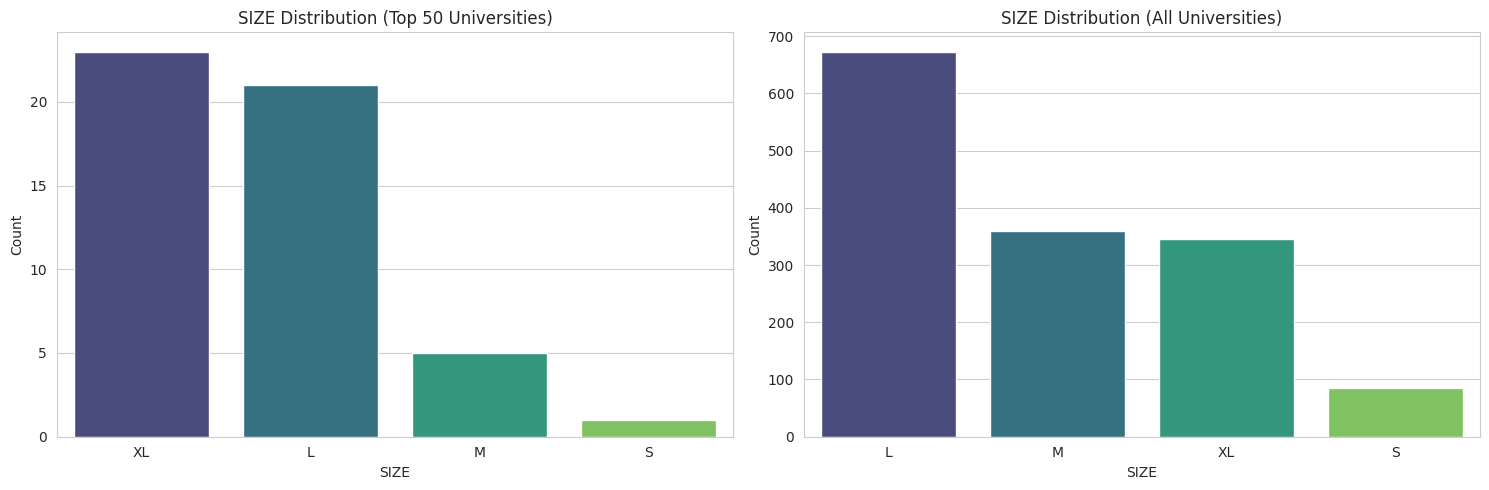

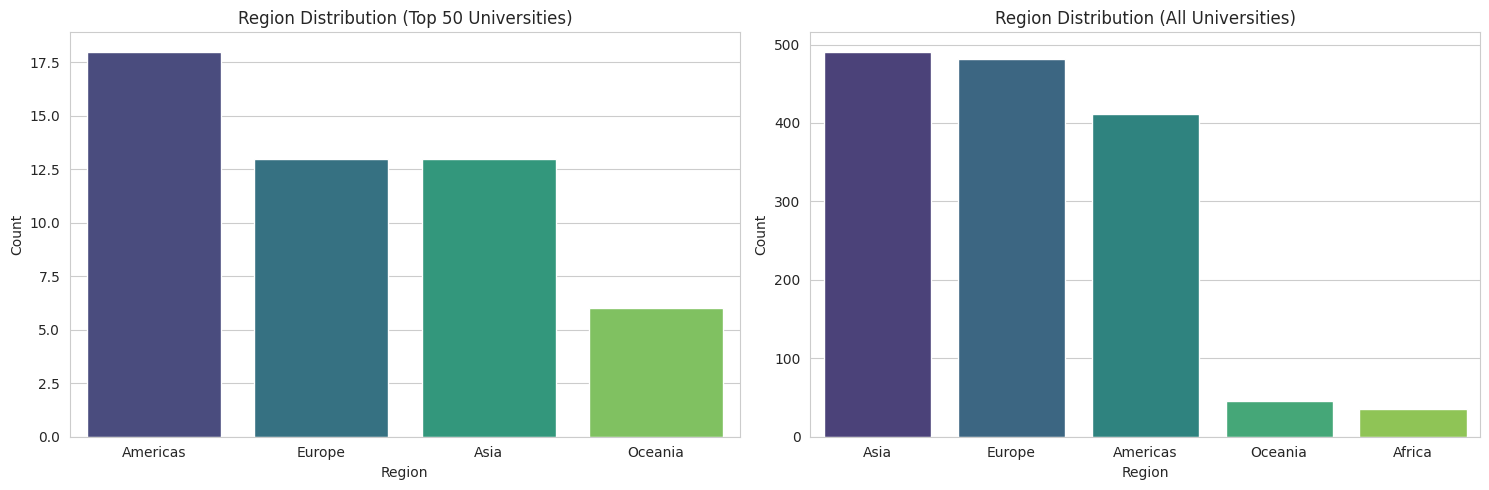

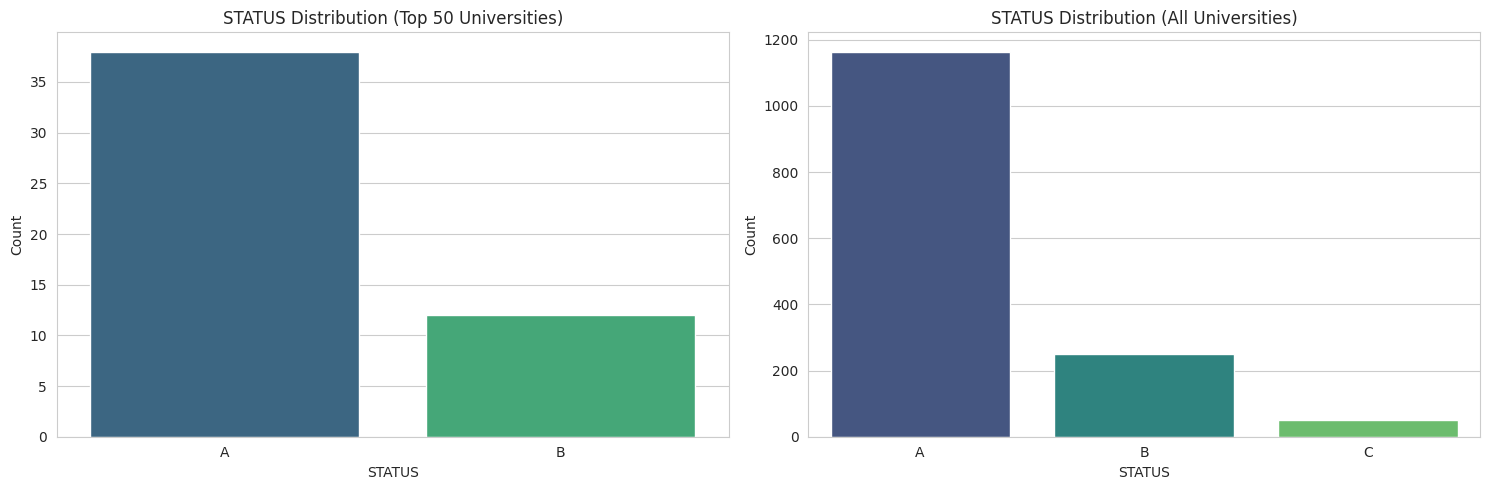

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to create comparison plots
def compare_distributions(column_name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # 1 row, 2 columns for side-by-side plots

    # Plot for df_top50
    sns.countplot(data=df_top50, x=column_name, ax=axes[0], palette='viridis',
                  order=df_top50[column_name].value_counts().index)
    axes[0].set_title(f'{column_name} Distribution (Top 50 Universities)')
    axes[0].set_ylabel('Count')

    # Plot for df_cat_cleaned (original dataset)
    sns.countplot(data=df_cat_cleaned, x=column_name, ax=axes[1], palette='viridis',
                  order=df_cat_cleaned[column_name].value_counts().index)
    axes[1].set_title(f'{column_name} Distribution (All Universities)')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

# Compare for each column
for column in ['SIZE', 'Region', 'STATUS']:
    compare_distributions(column)

In [15]:
import pandas as pd

def categorical_summary(df, columns):
    summary = {}
    for col in columns:
        summary[col] = df[col].value_counts(normalize=True)
    return summary

top50_summary = categorical_summary(df_top50, ['SIZE', 'Region', 'STATUS'])
cleaned_summary = categorical_summary(df_cat_cleaned, ['SIZE', 'Region', 'STATUS'])

# Create a list to store DataFrames for each column
dfs = []

for col in ['SIZE', 'Region', 'STATUS']:
    top50_df = pd.DataFrame(top50_summary[col]).reset_index()
    top50_df.columns = ['Category', 'Top 50 Percentage']

    cleaned_df = pd.DataFrame(cleaned_summary[col]).reset_index()
    cleaned_df.columns = ['Category', 'All Universities Percentage']

    merged_df = pd.merge(top50_df, cleaned_df, on='Category', how='outer').fillna(0)
    merged_df['Column'] = col  # Add a column to identify the category
    dfs.append(merged_df)

# Concatenate all DataFrames into a single table
final_table = pd.concat(dfs, ignore_index=True)

# Format percentages to two decimal places
final_table['Top 50 Percentage'] = final_table['Top 50 Percentage'].apply(lambda x: "{:.0f}%".format(x * 100))
final_table['All Universities Percentage'] = final_table['All Universities Percentage'].apply(lambda x: "{:.0f}%".format(x * 100))

# Add separators between groups
final_table = final_table.sort_values(by=['Column', 'Category'])  # Sort for better grouping
final_table = final_table.reset_index(drop=True)  # Reset index

# Insert blank rows for separators
separator_indices = final_table[final_table['Category'] == final_table['Column'].shift(1)].index[1:]  # Find separators
for i in separator_indices:
    final_table.loc[i - 0.5] = [final_table.loc[i, 'Column'], '', '', '']  # Insert blank rows

final_table = final_table.sort_index().reset_index(drop=True)  # Sort and reset index again

# Display the table
print(final_table)

    Category Top 50 Percentage All Universities Percentage  Column
0     Africa                0%                          2%  Region
1   Americas               36%                         28%  Region
2       Asia               26%                         34%  Region
3     Europe               26%                         33%  Region
4    Oceania               12%                          3%  Region
5          L               42%                         46%    SIZE
6          M               10%                         25%    SIZE
7          S                2%                          6%    SIZE
8         XL               46%                         24%    SIZE
9          A               76%                         79%  STATUS
10         B               24%                         17%  STATUS
11         C                0%                          4%  STATUS


In [20]:
import pandas as pd

# Define a function to summarize counts
def summarize_columns(df, label, columns):
    summary = []
    for col in columns:
        counts = df[col].value_counts(normalize=True).round(2) * 100
        temp_df = counts.rename(f"{label} (%)").to_frame()
        temp_df.index.name = 'Category'
        temp_df['Column'] = col
        summary.append(temp_df.reset_index())
    return pd.concat(summary)

# Columns to compare
columns_to_compare = ['SIZE', 'Region', 'STATUS']

# Create summaries
summary_all = summarize_columns(df, 'All', columns_to_compare)
summary_top50 = summarize_columns(df_top50, 'Top 50', columns_to_compare)
summary_top20 = summarize_columns(df_top20, 'Top 20', columns_to_compare)

# Merge summaries
merged = summary_all.merge(summary_top50, on=['Column', 'Category'], how='outer') \
                    .merge(summary_top20, on=['Column', 'Category'], how='outer')

# Fill missing values and sort
merged = merged.fillna(0).sort_values(['Column', 'Category'])

# Optional: format percentages nicely
merged['All (%)'] = merged['All (%)'].map('{:.0f}%'.format)
merged['Top 50 (%)'] = merged['Top 50 (%)'].map('{:.0f}%'.format)
merged['Top 20 (%)'] = merged['Top 20 (%)'].map('{:.0f}%'.format)

# Display the final table with multi-index
final_table = merged.set_index(['Column', 'Category'])
print("\nFull Comparison Table:\n")
print(final_table)


Full Comparison Table:

                      All (%) Top 50 (%) Top 20 (%)
Column Category                                    
Region Africa              3%         0%         0%
       Americas           28%        36%        35%
       Asia               33%        26%        25%
       Europe             33%        26%        25%
       Not Classified      0%         0%         0%
       Oceania             3%        12%        15%
SIZE   L                  46%        42%        50%
       M                  25%        10%         5%
       S                   6%         2%         5%
       XL                 23%        46%        40%
STATUS A                  79%        76%        70%
       B                  17%        24%        30%
       C                   4%         0%         0%


In [29]:
# Count nulls in interested columns
#null_counts = df[['RANK_2025', 'Employment_Outcomes_Score']].isnull().sum()

# Display the result
#print(null_counts)

In [ ]:
# Not needed to drop any NAs because none exist from code above
#columns_to_check = ['Overall_Score', 'Academic_Reputation_Score', 'Employer_Reputation_Score','Faculty_Student_Score', 'Citations_per_Faculty_Score', 'International_Faculty_Score', 'International_Students_Score', 'International_Research_Network_Score', 'Employment_Outcomes_Score', 'Sustainability_Score']
#df_cleaned = df.dropna(subset=columns_to_check)
#print(f"Shape of the dataset after dropping nulls: {df_cleaned.shape}")

In [28]:
#going back to df_cleaned
import statsmodels.formula.api as sm

# Define the formula for the model
formula = 'Overall_Score ~ Employment_Outcomes_Score'

# Fit the OLS model
model = sm.ols(formula, data=df_cleaned)
results = model.fit()

# Print the summary of the model
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Overall_Score   R-squared:                       0.392
Model:                            OLS   Adj. R-squared:                  0.391
Method:                 Least Squares   F-statistic:                     380.7
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           8.02e-66
Time:                        02:57:05   Log-Likelihood:                -2434.5
No. Observations:                 593   AIC:                             4873.
Df Residuals:                     591   BIC:                             4882.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [31]:
df_top50[['RANK_2025','RANK_2024','Employment_Outcomes_Score','Overall_Score']].describe()

,RANK_2025,RANK_2024,Employment_Outcomes_Score,Overall_Score
count,50.000000,50.000000,50.000000,50.000000
mean,25.420000,25.660000,83.796000,85.488000
std,14.502765,15.140984,20.290412,6.285865
min,1.000000,1.000000,27.200000,76.000000
25%,13.250000,13.250000,71.825000,81.050000
50%,25.500000,25.500000,94.350000,83.800000
75%,37.750000,37.750000,98.650000,88.800000
max,50.000000,60.000000,100.000000,100.000000
